# Bloc 3 - Plan - Prep des features

1.Traiter les inf (floor_surface)  
2.Traiter les NaN (NumberofBuildings, SiteEnergyUse, SecondLargestGFA, ThirdLargestGFA)  
3.Traiter les outliers (quantiles recommandé)  
4.Encoder les catégorielles (OneHotEncoder avec max_categories)  
5.Scaler les numériques  
6.Split train/test  
7.Bilan : shape, zéro NaN, tout numérique  

In [40]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [41]:
# profiling rapide
def info(df, name):
    print(f"Dataset: {name} - {df.shape[0]} rows {df.shape[1]} columns")
    profil = pd.DataFrame({ 
        'columns': df.columns.values,
        'non_null': df.notnull().sum().values,
        'nan': df.isna().sum().values,
        'nan %': (df.isna().sum() / len(df) * 100).values.round(1), 
        'unique':(df.nunique() / len(df) * 100).values.round(1), 
        'types':df.dtypes.values,
        'types_length': df.apply(lambda col:(col.astype(str).str.len().max())).values
    })
    return profil

In [42]:
# chargement du df
df = pd.read_csv('../data/df_s4.csv')

# profiling du df
info(df, 'df de départ')

Dataset: df de départ - 1666 rows 16 columns


,columns,non_null,nan,nan %,unique,types,types_length
0,building_age,1666,0,0.0,6.8,int64,3
1,BuildingType,1666,0,0.0,0.3,str,18
2,floor_surface,1666,0,0.0,96.6,float64,18
3,has_third_use,1666,0,0.0,0.1,int64,1
4,Neighborhood,1666,0,0.0,1.1,str,22
5,NumberofBuildings,1666,0,0.0,1.0,float64,5
6,NumberofFloors,1666,0,0.0,2.7,int64,2
7,PrimaryPropertyType,1666,0,0.0,1.3,str,27
8,ratio_build,1666,0,0.0,19.9,float64,18
9,SecondLargestPropertyUseTypeGFA,1666,0,0.0,42.0,float64,11


Pour fonctionner avec les modèles ont doit respecter les critères suivants:
- Tout numérique > toutes les donnnées
- Aucun NaN
- Aucun inf
- Lignes X (features) =  lignes y (target).
- Target(y) séparée les (X)features, et vive versa.

Les étapes 1(nan) et 2(inf) sont ont été reglés dans le bloc 2.  

#### Step 1 *outliers*
Il faut élaborer une approche pour les outliers qui sont nombreux mais naturels.

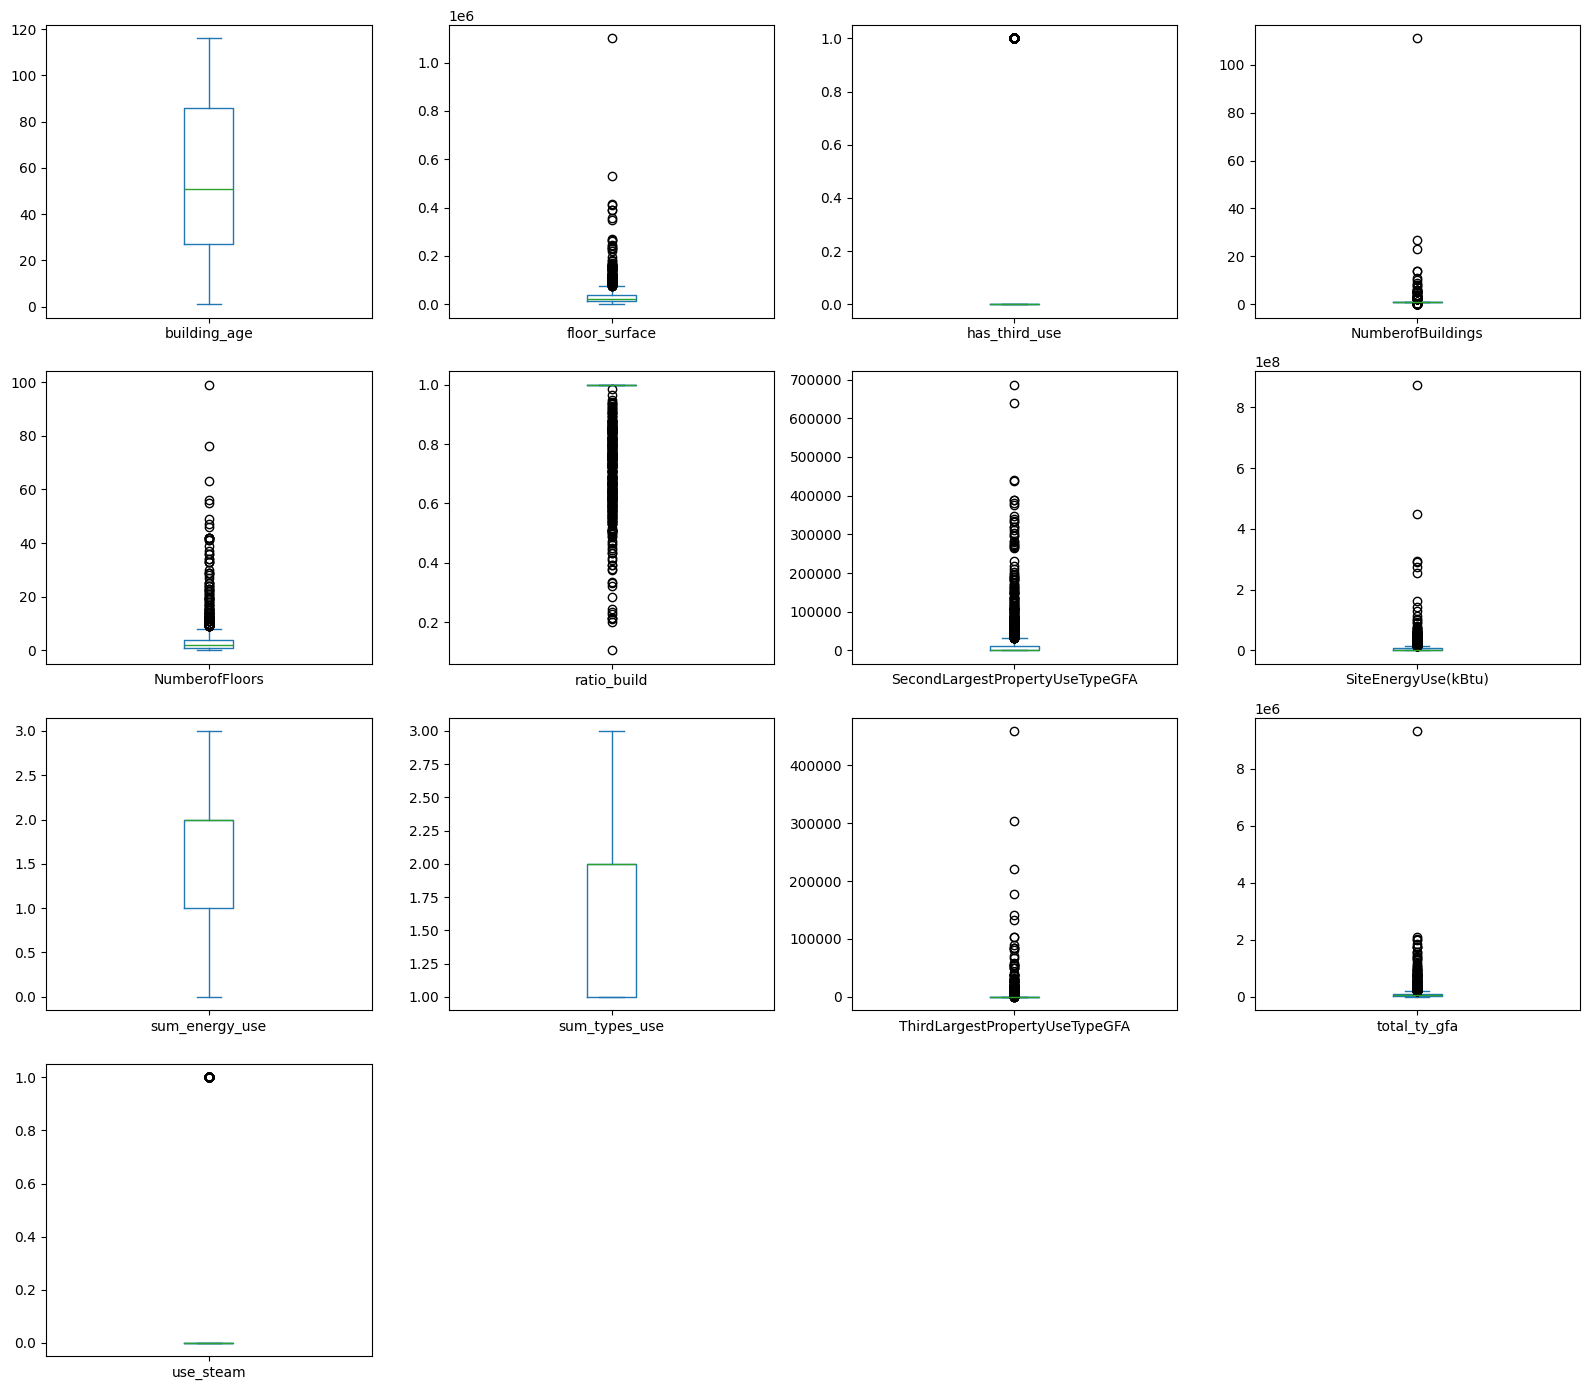

In [43]:
# boxplot pour les outlier juste pour identifier les colonnes sr le nouveau df
df.plot(kind = 'box', subplots = True, layout = (4, 4), figsize = (16, 14))
plt.tight_layout()
plt.show()

Comme les outliers sont utiles, ils seront garder et log-transformer, c'est à dire compressé les grandes valeurs et etirer les petites afin de rendre la feature plus symmétrique, et donc lisible pour le modèle (linéaire pour les modèles en arbre ca ne pose pas de problèmes) . 


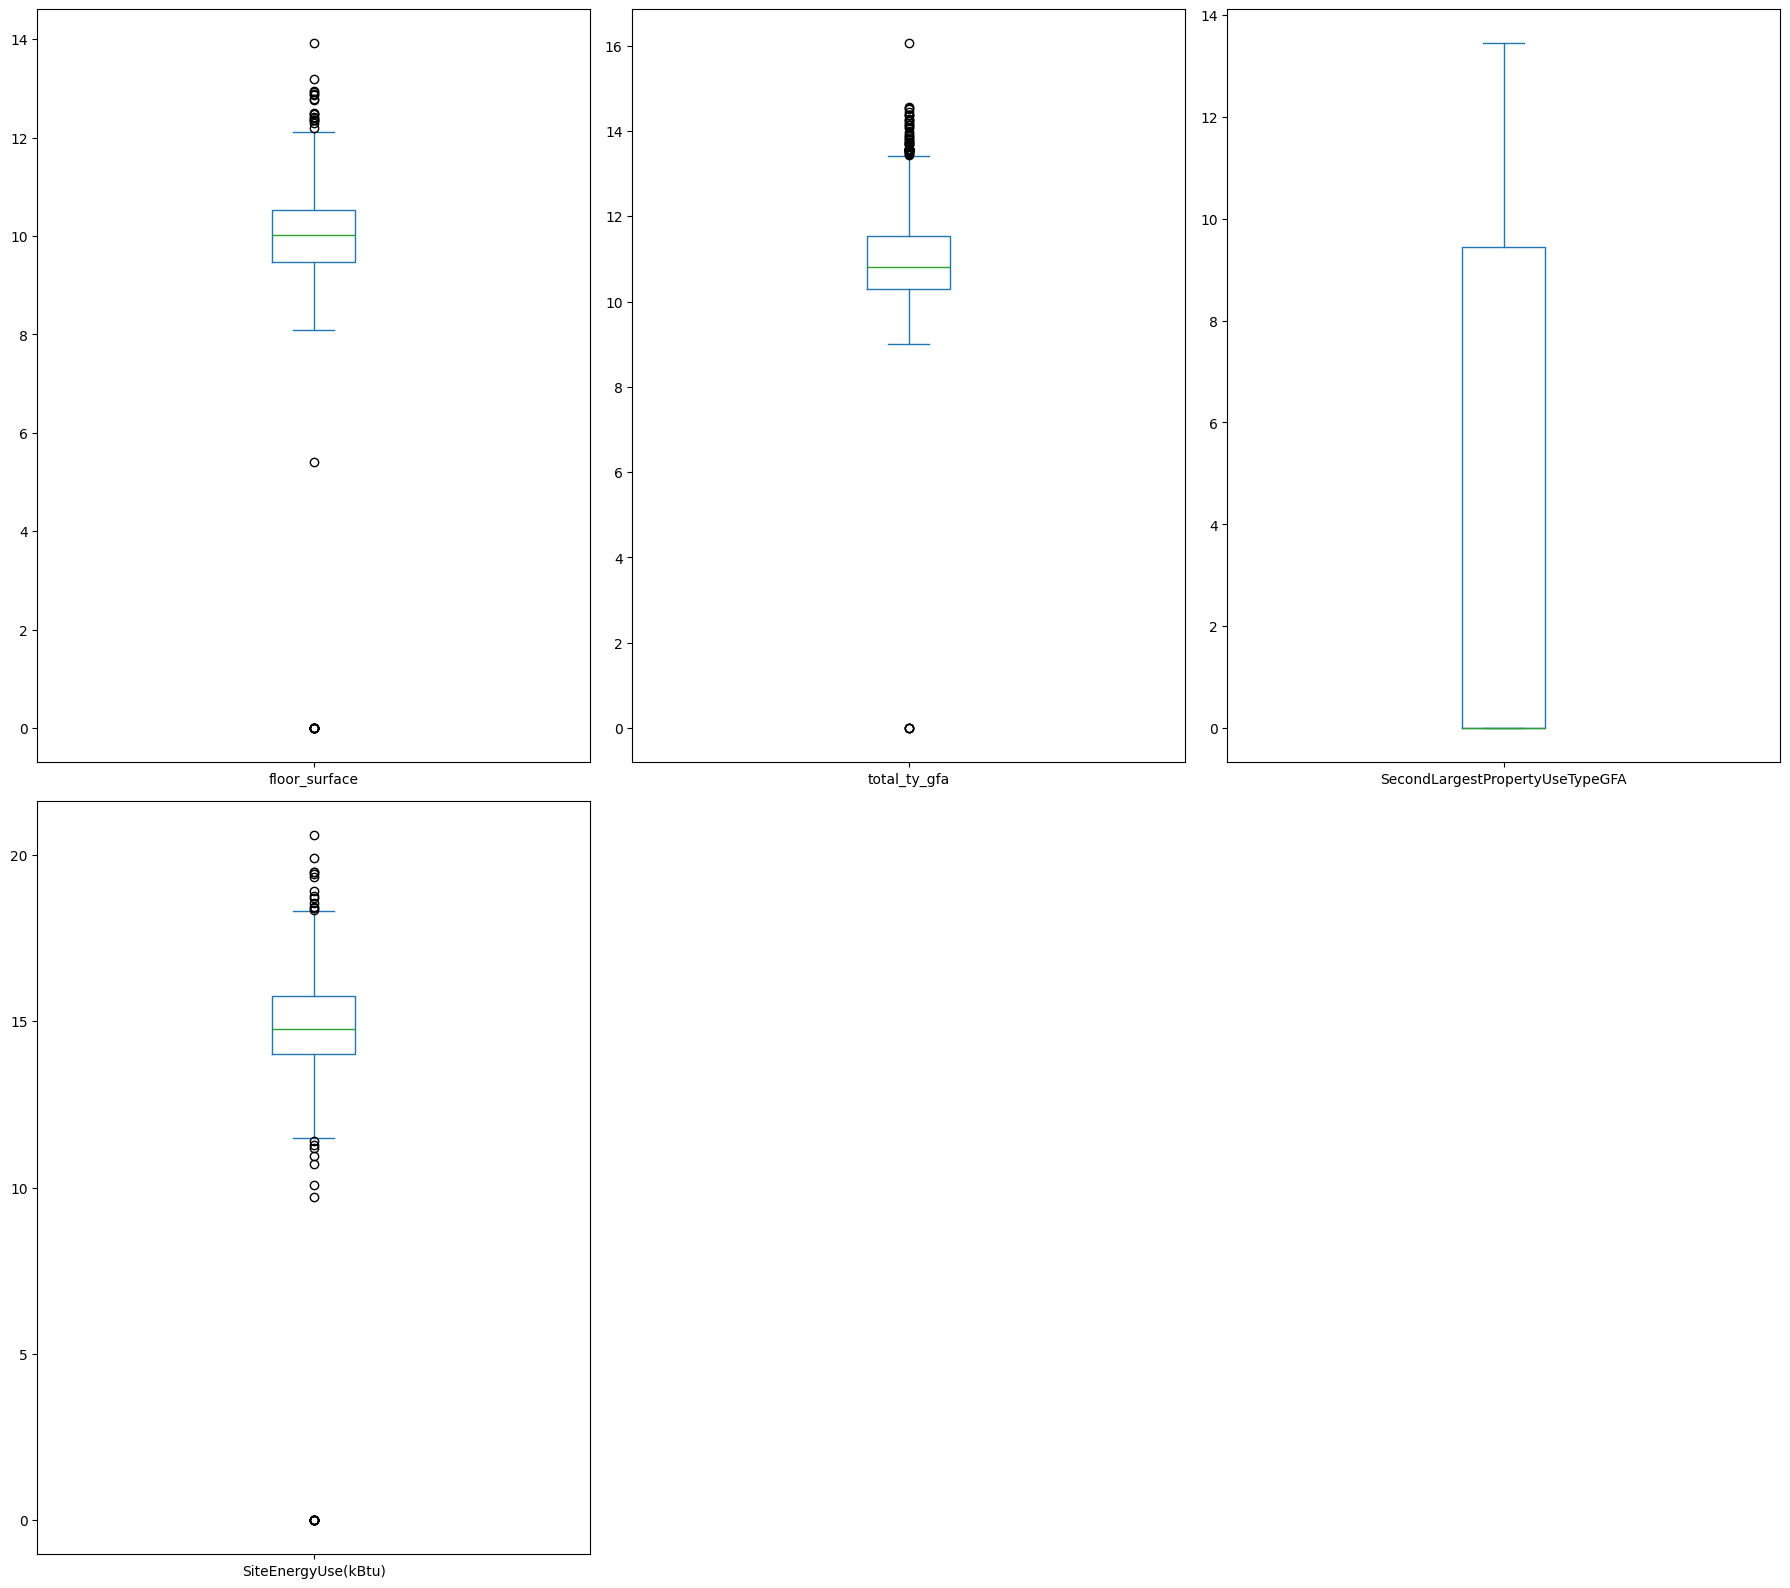

In [44]:
cols_on_log = [
    'floor_surface',
    'total_ty_gfa',
    'SecondLargestPropertyUseTypeGFA',
    'SiteEnergyUse(kBtu)',
]

cols_off_log = [
    'building_age',
    'NumberofBuildings',
    'NumberofFloors',
    'ratio_build',
    'use_steam',
    'has_third_use',
    'sum_energy_use',
    'sum_types_use',
    'ThirdLargestPropertyUseTypeGFA'
] 

df[cols_on_log] = np.log1p(df[cols_on_log])

# contrôle de nouveaux
df[cols_on_log].plot(kind = 'box', subplots = True, layout = (2, 3), figsize = (18, 16))
plt.tight_layout()
plt.show()

In [53]:
df.nlargest(5,'SiteEnergyUse(kBtu)')

,building_age,BuildingType,floor_surface,has_third_use,Neighborhood,NumberofBuildings,NumberofFloors,PrimaryPropertyType,ratio_build,SecondLargestPropertyUseTypeGFA,SiteEnergyUse(kBtu),sum_energy_use,sum_types_use,ThirdLargestPropertyUseTypeGFA,total_ty_gfa,use_steam
34,24,Campus,12.013373,1,GREATER DUWAMISH,1.0,3,Mixed Use Property,1.0,13.369117,19.921163,2,3,459748.0,14.434315,0
168,16,NonResidential,11.883367,0,EAST,9.0,8,Hospital,1.0,12.867863,19.495993,3,2,0.0,14.368150,1
607,22,NonResidential,11.745161,0,EAST,7.0,14,Hospital,1.0,12.998051,19.490943,3,2,0.0,14.548304,1
548,35,NonResidential,9.473725,0,DOWNTOWN,1.0,33,Other,1.0,12.256813,19.431125,2,2,0.0,12.970160,0
123,63,NonResidential,11.383966,0,NORTHEAST,6.0,10,Hospital,1.0,0.000000,19.352185,2,1,0.0,13.686541,0


In [ ]:
df = df.drop(index = 1625)

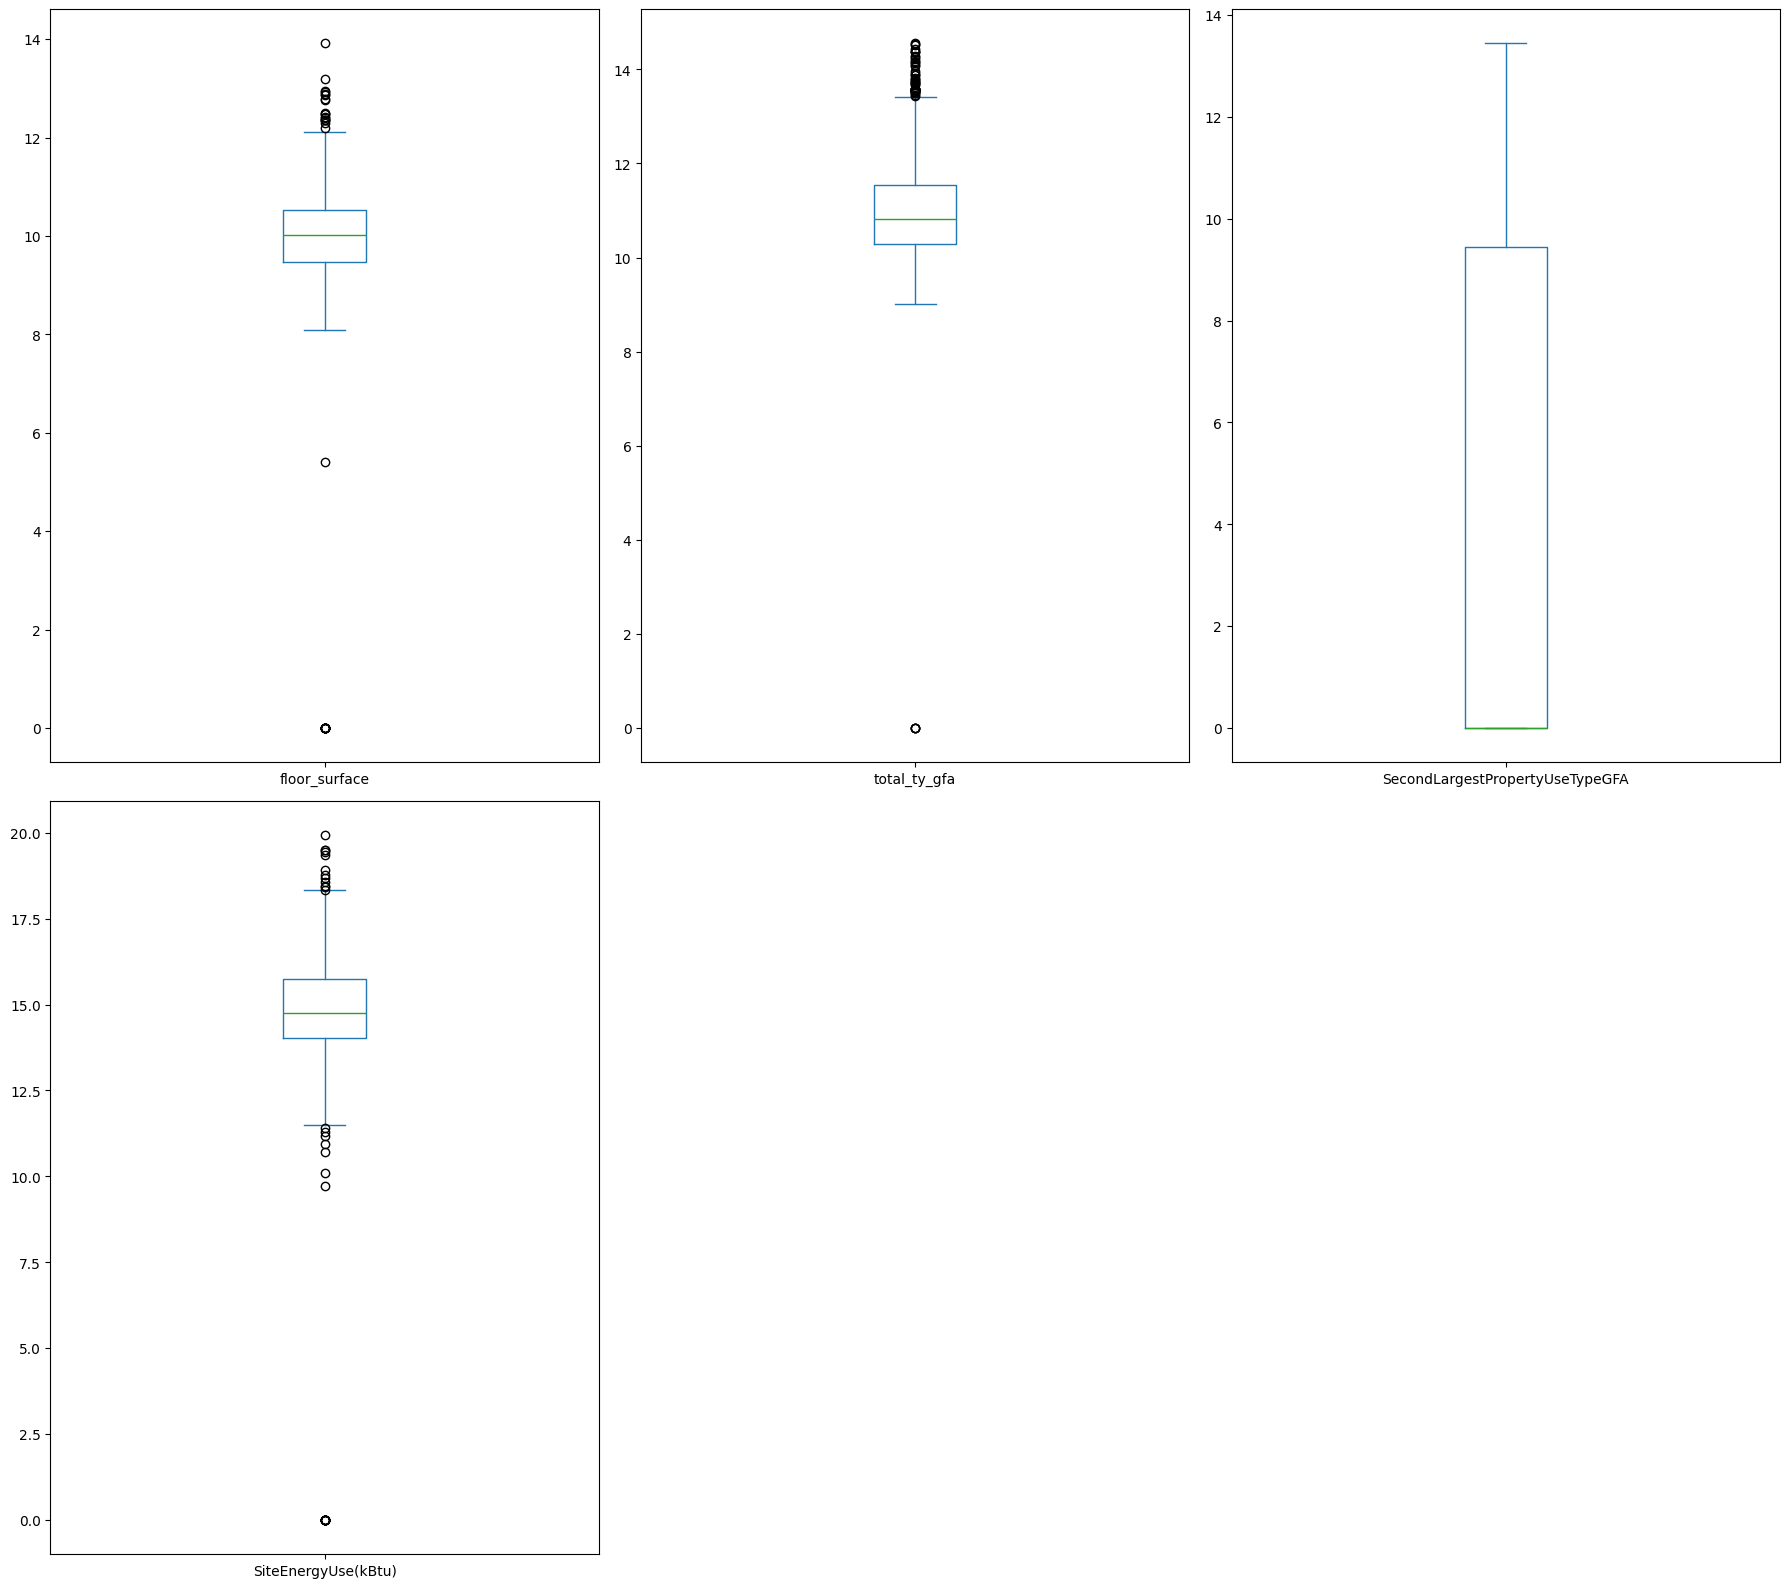

<class 'pandas.DataFrame'>
Index: 1665 entries, 0 to 1665
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   building_age                     1665 non-null   int64  
 1   BuildingType                     1665 non-null   str    
 2   floor_surface                    1665 non-null   float64
 3   has_third_use                    1665 non-null   int64  
 4   Neighborhood                     1665 non-null   str    
 5   NumberofBuildings                1665 non-null   float64
 6   NumberofFloors                   1665 non-null   int64  
 7   PrimaryPropertyType              1665 non-null   str    
 8   ratio_build                      1665 non-null   float64
 9   SecondLargestPropertyUseTypeGFA  1665 non-null   float64
 10  SiteEnergyUse(kBtu)              1665 non-null   float64
 11  sum_energy_use                   1665 non-null   int64  
 12  sum_types_use                    166

In [48]:
df[cols_on_log].plot(kind = 'box', subplots = True, layout = (2, 3), figsize = (18, 16))
plt.tight_layout()
plt.show()

df.info()

Malgré le log on retrouve des outliers :  

L'University of Washington compte en réalité plus de 500 bâtiments sur ses campus( l'electicité consommée n'est structurelement pas bonne dans le dataset si il compte 111 bâtiment), alors que le dataset n'en déclare que 111. La donnée ne reflète même pas la réalité du site — elle est à la fois structurellement incompatible avec le format une ligne = un bâtiment, et factuellement sous-estimée. Cette  entrée est retirée car non modélisable (index numéro 1625). Là il y a un problème de compliance.

Toutefois on constate que les données ont bien été normalisé mêmes parmi les outliers. Ce qui étirent les box ce sont surtout les 0 ce qui est normal quand il y a pas de données. 

Transformation : 
- colonnes en valeurs continue sont normalisées
- supression de l'index 1625 (Université de Washington)

Step 2 